In [52]:
# ==================
# IMPORTS
# ==================
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

In [53]:
# ==================
# CONFIGURATION
# ==================
warnings.filterwarnings("ignore")

ACCENT_PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff', '#f85149', '#56d4dd']

plt.rcParams.update({
    'figure.facecolor': '#0d1117',

    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'axes.prop_cycle': plt.cycler(color=ACCENT_PALETTE),

    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',

    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#cccccc',
    'grid.linestyle': "--",
    'grid.alpha': 0.75,

    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',

    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

sns.set_palette(ACCENT_PALETTE)

In [54]:
# ==================
# DATA PREPARATION
# ==================
def load_data(path: str) -> pd.DataFrame:
    data_path = Path(path)
    if not data_path.exists():
        raise FileNotFoundError(f"{data_path} does not exist")

    return pd.read_csv(path)

merged = load_data("../data/cleaned_data/cleaned_merged_data.csv")

In [55]:
# ==================
# DATA ANALYSIS
# ==================
merged.info()
merged.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4494 entries, 0 to 4493
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country_code                    4494 non-null   str    
 1   country_name                    4494 non-null   str    
 2   iso3                            4494 non-null   str    
 3   region                          4494 non-null   str    
 4   income_group                    4494 non-null   str    
 5   year                            4494 non-null   int64  
 6   gdp_growth                      4494 non-null   float64
 7   inflation                       4494 non-null   float64
 8   unemployment                    4494 non-null   float64
 9   gdp_per_capita                  4494 non-null   float64
 10  population                      4494 non-null   float64
 11  food_production_index           4494 non-null   float64
 12  cereal_yield                    4494 non-null

,year,gdp_growth,inflation,unemployment,gdp_per_capita,population,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,...,economic_stress_score,data_completeness_score,latitude,longitude,inflation_score,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score
count,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,...,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000,4494.000000
mean,2012.026925,3.339532,4.624181,7.640560,8.668561,15.199454,94.931489,3067.624043,13.688935,36.146196,...,49.571377,91.001335,18.854043,19.622417,50.273866,50.267448,49.759416,49.762920,49.711706,49.571377
std,6.048505,3.830183,4.135653,4.925379,1.552349,2.385939,14.969708,1766.198038,3.129918,21.488304,...,14.964214,19.292194,23.984601,69.435916,26.680083,26.984215,28.453013,28.660854,19.891998,14.964214
min,2002.000000,-5.126665,-0.273250,1.525800,4.705864,9.172015,63.460000,686.520000,0.000000,0.069900,...,0.470000,15.000000,-41.286500,-175.216000,0.520833,0.534759,0.000000,0.000000,0.000000,0.470000
25%,2007.000000,1.220723,1.755078,4.102500,7.458499,13.626930,85.780000,1688.650000,12.647104,18.174800,...,39.530000,100.000000,4.609870,-13.213400,29.508197,28.877005,25.490196,25.118483,35.771222,39.530000
50%,2012.000000,3.529681,3.333744,6.375000,8.656183,15.612647,97.010000,2776.100000,14.370603,37.265350,...,49.560000,100.000000,17.300000,19.259500,50.273224,50.267380,49.760766,49.762469,50.166333,49.560000
75%,2017.000000,5.855691,6.532772,9.956250,9.955301,16.886701,103.980000,3917.850000,15.334344,51.013775,...,59.670000,100.000000,39.715300,49.893200,71.038251,71.657754,74.019608,74.407583,63.396602,59.670000
max,2022.000000,10.299999,15.438486,19.620950,12.328525,21.077735,122.410500,7175.080000,20.264554,84.706600,...,99.050000,100.000000,64.183600,179.089567,100.000000,100.000000,99.526066,99.532710,99.487179,99.050000


In [56]:
# ==================
# DROPPING
# ==================
merged = merged.drop(columns=[
    "iso3", "country_name", "country_code", "region", "final_economic_stress_score",
    "inflation_score", "unemployment_score", "gdp_growth_score", "income_vulnerability_score"
])

In [57]:
# ==================
# ENCODING
# ==================
print(merged["income_group"].value_counts())

merged = pd.get_dummies(merged, columns=["income_group"], drop_first=True)
merged.columns = merged.columns.str.replace(" ", "_")
print("")
print(merged.columns)

income_group
High income            1744
Upper middle income    1133
Lower middle income    1050
Low income              525
Not classified           42
Name: count, dtype: int64

Index(['year', 'gdp_growth', 'inflation', 'unemployment', 'gdp_per_capita',
       'population', 'food_production_index', 'cereal_yield',
       'cereal_production_tonnes', 'agricultural_land_pct',
       'dietary_energy_supply_adequacy', 'economic_stress_score',
       'data_completeness_score', 'latitude', 'longitude',
       'food_pressure_score', 'income_group_Low_income',
       'income_group_Lower_middle_income', 'income_group_Not_classified',
       'income_group_Upper_middle_income'],
      dtype='str')


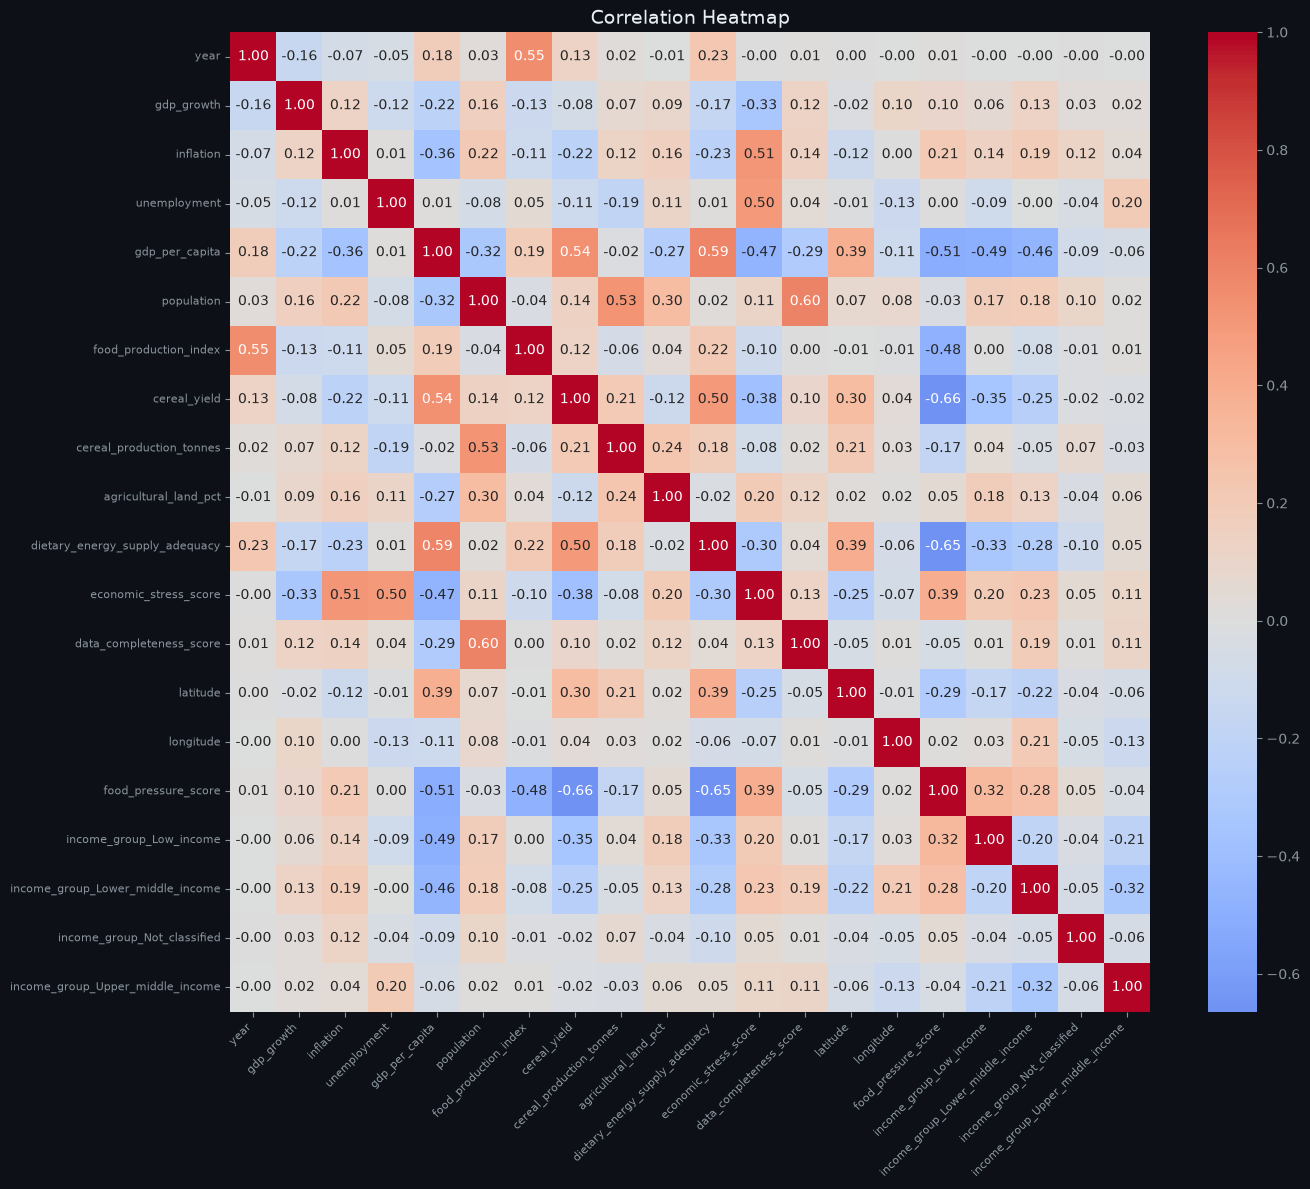

In [58]:
# ==================
# DATA CORR
# ==================
merged_corr = merged.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    merged_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

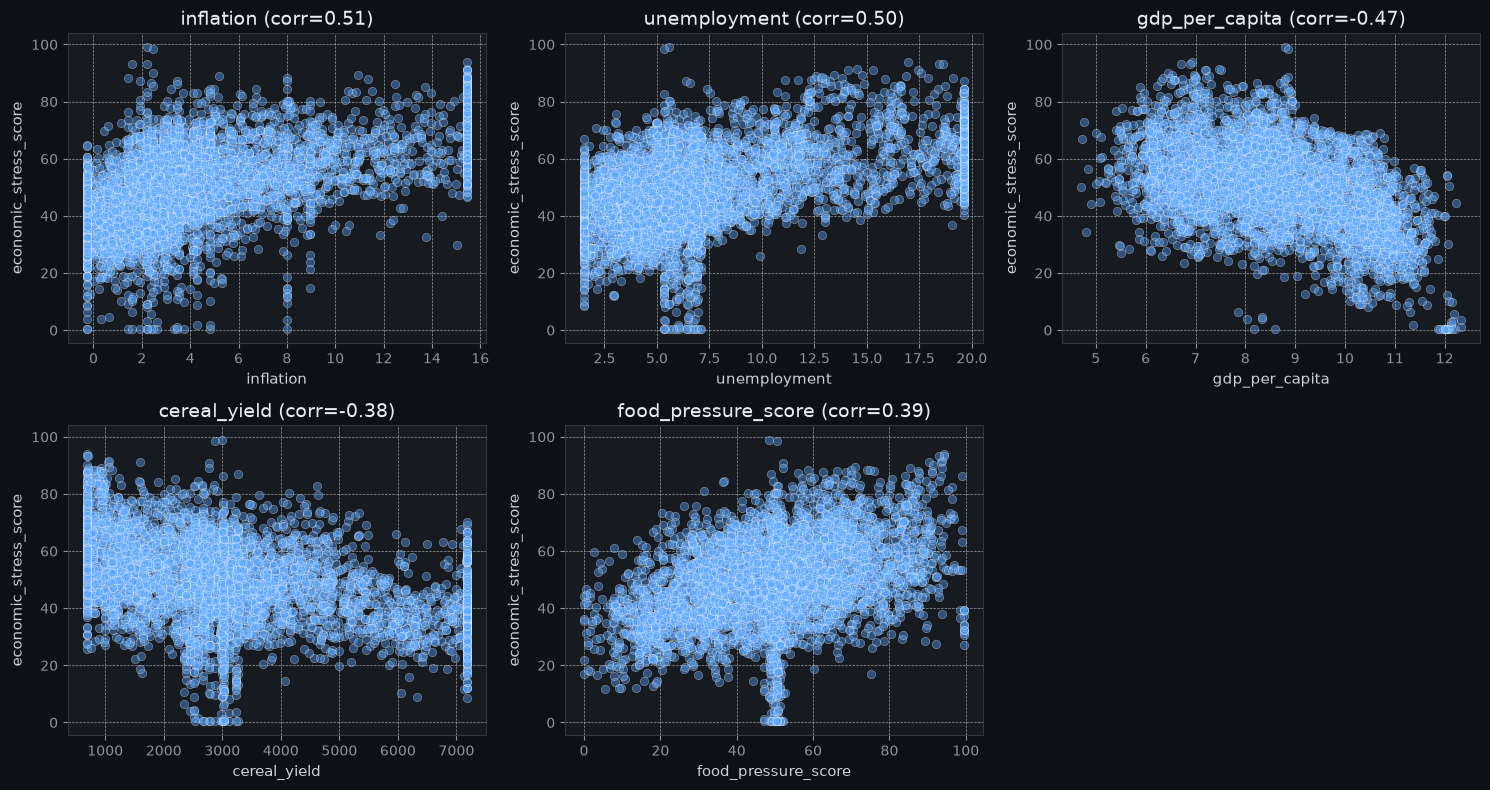

In [59]:
top_features = ["inflation", "unemployment", "gdp_per_capita",
    "cereal_yield", "food_pressure_score"]

n_cols = 3
n_rows = -(-len(top_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.scatterplot(x=col, y="economic_stress_score", data=merged, alpha=0.4, ax=axes[i])
    corr_val = merged[col].corr(merged["economic_stress_score"])
    axes[i].set_title(f"{col} (corr={corr_val:.2f})")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [60]:
# ==================
# NEW FEATURES
# ==================
merged["inflation_unemployment"] = merged["inflation"] * merged["unemployment"]
merged["inflation_minus_growth"] = merged["inflation"] - merged["gdp_growth"]
merged["inflation_squared"] = merged["inflation"] ** 2

In [61]:
print(merged["inflation_unemployment"].corr(merged["economic_stress_score"]))
print(merged["inflation_minus_growth"].corr(merged["economic_stress_score"]))
print(merged["inflation_squared"].corr(merged["economic_stress_score"]))

0.6270008316709293
0.6461134979718123
0.46377742535734856


In [62]:
# ==================
# SAVING DATAFRAME
# ==================
Path("../data/processed_data").mkdir(parents=True, exist_ok=True)
merged.to_csv("../data/processed_data/processed_merged_data.csv", index=False)